# The DHS hiring surge in ICE & CBP: how big, did it stick, and who is leaving?

**The question.** In 2025 the Department of Homeland Security launched a large hiring push,
concentrated in ICE and CBP, and the numbers were publicly disputed. Using federal personnel
records we ask three things:

1. **How big was the surge**, compared with normal ICE and CBP hiring?
2. **Did it stick** — did the new hires actually show up on the payroll, and are they *staying*?
3. **Who is leaving** — are the people leaving the *surge hires themselves*, are they **quitting or
   being let go**, and is the departure rate **higher than for similar hires**?

**The data.** OPM/EHRI personnel records, published monthly and mirrored at
[`impactproject/opm-ehri-data`](https://huggingface.co/datasets/impactproject/opm-ehri-data).
Three files: **hires** (OPM calls them *accessions*), **departures** (*separations*), and a monthly
**headcount** snapshot. Each row is a *count of people* sharing a set of attributes (job, grade, pay
plan, etc.) — **not** an individual record, so we can't literally follow one person from hire to exit.
We work around that by identifying the surge hires through the **jobs they were hired into** (§3).

Method, checks, and definitions are in the README; §0 below runs the checks live against the data.

In [1]:
import sys; sys.path.insert(0, "src")
import surge
import json
import pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mtick, matplotlib.dates as mdates
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 30)

# ---- tables: thousands separators, whole numbers (no trailing ".0"), % where asked ----
def show(df, pct=(), index=False, na_rep="—"):
    """Render a DataFrame as a tidy HTML table. Numeric columns get thousands separators;
    columns that are whole numbers lose the trailing '.0'; columns named in `pct` get a % sign."""
    fmt = {}
    for c in df.columns:
        col = df[c]
        if c in pct:
            fmt[c] = lambda v: "" if pd.isna(v) else f"{v:,.1f}%"
        elif pd.api.types.is_numeric_dtype(col):
            s = col.dropna()
            whole = len(s) > 0 and bool((s == s.round()).all())
            fmt[c] = (lambda v: "" if pd.isna(v) else f"{int(round(v)):,}") if whole \
                     else (lambda v: "" if pd.isna(v) else f"{v:,.1f}")
    sty = df.style.format(fmt, na_rep=na_rep)
    return sty if index else sty.hide(axis="index")

def ym_label(ym):  # "202512" -> "Dec 2025"
    return pd.to_datetime(str(ym), format="%Y%m").strftime("%b %Y")

# Occupational-series names, so tables show what a job code means (USAJOBS codelist, pulled by src/history.py).
occ_names = pd.read_csv("data/occ_series_names.csv", dtype=str).set_index("code")["name"].to_dict()
def series_label(code):  # "1801" -> "1801 — General Inspection, Investigation, Enforcement, and Compliance Series"
    name = occ_names.get(str(code))
    return f"{code} — {name}" if name else str(code)

# ---- charts: a lighter, less cluttered theme + a small consistent palette ----
C_ICE, C_CBP, C_EXIT, C_MUTED, C_ALT = "#2166ac", "#e08214", "#c0392b", "#8a8f98", "#7b6db5"
SPAN = "#fdd9a0"  # shading for the surge window
plt.rcParams.update({
    "figure.dpi": 120, "savefig.bbox": "tight", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#bbbbbb",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelcolor": "#444", "axes.labelsize": 10, "xtick.color": "#444", "ytick.color": "#444",
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#dddddd", "grid.linewidth": 0.7,
    "legend.frameon": False,
})
def comma_y(ax):  # 30000 -> "30,000" on the y-axis
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
def int_x(ax):    # whole years on the x-axis (2010, not 2010.0)
    ax.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x)}"))
def date_x(ax):   # clean, non-overlapping month/year labels on a date x-axis
    loc = mdates.AutoDateLocator()   # default bounds pick sensible intervals without warning
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

con = surge.con()
def q(sql): return con.execute(sql).df()
def scalar(sql): return con.execute(sql).fetchone()[0]  # for single-value queries -- no .iloc[0,0] noise at call sites
ACC, SEP, EMP = surge.ACC, surge.SEP, surge.EMP

# ---- shared filter fragments, built once so no cell re-derives or hardcodes them ----
IS_ICE = f"agy_code='{surge.ICE}'"
ICE_HIRE = f"{IS_ICE} AND {surge.NEW_HIRE}"          # ACC: any genuine ICE new hire
FP = surge.SURGE_FP                                   # the surge-hire profile: pay plan GL, series 1801/1811
ICE_FP_HIRE = f"{ICE_HIRE} AND {FP}"                  # ACC: ICE new hires into the surge profile
ICE_FP_SEP = f"{IS_ICE} AND {FP}"                     # SEP: ICE departures from the surge profile
SURGE_WINDOW_SQL = f"event_ym BETWEEN '{surge.SURGE_WINDOW[0]}' AND '{surge.SURGE_WINDOW[1]}'"  # Sep 2025 - Jan 2026
POST_SURGE = f"event_ym >= '{surge.SURGE_WINDOW[0]}'"  # the cohort-tracking window: Sep 2025 through the latest month
PRE_SURGE_MONTH = "202508"                             # Aug 2025 -- the last month before the surge began

print("Cached extract:", ACC.split("/")[-1], "|", SEP.split("/")[-1], "|", EMP.split("/")[-1])
print("Latest month in data:", ym_label(surge.LATEST_MONTH), "(the most recent 1-2 months are provisional)")

Cached extract: acc_ice_cbp.parquet | sep_ice_cbp.parquet | emp_ice_cbp.parquet
Latest month in data: Jul 2026 (the most recent 1-2 months are provisional)


## 0. Method checks

Every assumption this analysis leans on is checked against the data live, below, not just asserted — full rationale for each is in the README. Five checks: agency codes are stable and exclusive (①), summing across files by effective date doesn't double-count (②), the headcount decline is real and not a reporting artifact (③), redaction preserves totals while the surge is genuine new hires, not transfers (④), and the departures we attribute to the surge cohort in §4 aren't mostly ordinary turnover from the people already in these jobs before the surge (⑤).

In [2]:
# CHECK 1 — agency identity & code stability. This audit (built offline by src/history.py, which scans
# the raw yearly files) lists EVERY DHS/DOJ office whose name mentions immigration/customs/border. It
# confirms ICE=HSBB and CBP=HSBD are the only ICE/CBP codes, stable back to 2008, and that lookalikes
# (USCIS=HSAB, DOJ immigration courts=DJ12) are separate agencies our code filter correctly excludes.
# NOTE: we match with regexp_matches(...), NOT `SIMILAR TO '%...%'` — in DuckDB SIMILAR TO is a regex and
# `%` is a literal, so that pattern silently matches nothing (a bug we hit and fixed).
audit = pd.read_csv("data/agency_code_audit.csv", dtype=str)
audit["accessions"] = pd.to_numeric(audit["accessions"], errors="coerce")
piv = (audit.pivot_table(index=["code","agency_name"], columns="year",
                         values="accessions", aggfunc="first").reset_index())
piv.columns.name = None
display(show(piv, na_rep=""))  # blank (not "—") for years an agency had no matching hires
print("Codes ever matching immigration/customs/border:", sorted(audit.code.unique()))
print("=> ICE=HSBB and CBP=HSBD only; stable 2008-2026; HSAB (USCIS) and DJ12 (DOJ courts) are excluded.")
print("The cached extract contains exactly:",
      "; ".join(f"{r.agy_code}={r.agency}" for _,r in q(f"SELECT DISTINCT agy_code, agency FROM '{ACC}' ORDER BY 1").iterrows()))

code,agency_name,2008,2012,2016,2018,2020,2022,2024,2025
DJ12,EXECUTIVE OFFICE FOR IMMIGRATION REVIEW,16,4,2,1,56,12,25,
HSAB,BUREAU OF CITIZENSHIP AND IMMIGRATION SERVICES,218,,,,,,,
HSAB,CITIZENSHIP AND IMMIGRATION SERVICES,,164,92,162,7,229,949,1
HSBB,BUREAU OF IMMIGRATION AND CUSTOMS ENFORCEMENT,196,,,,,,,
HSBB,IMMIGRATION AND CUSTOMS ENFORCEMENT,,53,26,73,85,65,216,192
HSBD,BUREAU OF CUSTOMS AND BORDER PROTECTION,723,,,,,,,
HSBD,CUSTOMS AND BORDER PROTECTION,,243,128,324,448,329,472,516


Codes ever matching immigration/customs/border: ['DJ12', 'HSAB', 'HSBB', 'HSBD']
=> ICE=HSBB and CBP=HSBD only; stable 2008-2026; HSAB (USCIS) and DJ12 (DOJ courts) are excluded.
The cached extract contains exactly: HSBB=IMMIGRATION AND CUSTOMS ENFORCEMENT; HSBD=CUSTOMS AND BORDER PROTECTION


In [3]:
# CHECK 2 — files add new actions, they don't re-state the whole history. For a normal, mature month and
# for the December-2025 surge month, show how that month's hires are split across the files that reported
# them. If files re-stated history, one file would hold ~100% every time.
rows = []
for ym in ["202503", "202512"]:
    d = q(f"SELECT file_ym, SUM(count) n FROM '{ACC}' WHERE event_ym='{ym}' GROUP BY 1 ORDER BY 1")
    for _, r in d.iterrows():
        rows.append({"Hires effective": ym_label(ym), "Reported in file": ym_label(r.file_ym),
                     "Hires in that file": int(r.n),
                     "Share of the month": round(100*r.n/d.n.sum(), 1)})
display(show(pd.DataFrame(rows), pct=["Share of the month"]))
print("Mar 2025: ~98% lands in its own file (later files add small, DIFFERENT stragglers -> no double-count).")
print("Dec 2025: only ~30% lands in its own file; most December hires were processed in January.")
print("=> Summing across files is REQUIRED; using one file per month would badly undercount the surge.")

Hires effective,Reported in file,Hires in that file,Share of the month
Mar 2025,Mar 2025,498,97.5%
Mar 2025,Nov 2025,1,0.2%
Mar 2025,Feb 2026,5,1.0%
Mar 2025,Mar 2026,5,1.0%
Mar 2025,Jul 2026,2,0.4%
Dec 2025,Dec 2025,"1,067",29.2%
Dec 2025,Jan 2026,"1,952",53.3%
Dec 2025,Feb 2026,176,4.8%
Dec 2025,Mar 2026,233,6.4%
Dec 2025,Apr 2026,138,3.8%


Mar 2025: ~98% lands in its own file (later files add small, DIFFERENT stragglers -> no double-count).
Dec 2025: only ~30% lands in its own file; most December hires were processed in January.
=> Summing across files is REQUIRED; using one file per month would badly undercount the surge.


In [4]:
# CHECK 3 — how complete is a month after k months? (measured on settled 2024 months) + headcount de-dup.
mat = q(f"""
  WITH x AS (SELECT event_ym, SUM(count) n,
      (CAST(substr(file_ym,1,4) AS INT)*12+CAST(substr(file_ym,5,2) AS INT))
     -(CAST(substr(event_ym,1,4) AS INT)*12+CAST(substr(event_ym,5,2) AS INT)) AS lag
    FROM '{SEP}' WHERE event_ym BETWEEN '202401' AND '202411' GROUP BY 1, file_ym)
  SELECT lag AS "Months after the month", ROUND(100.0*SUM(SUM(n)) OVER (ORDER BY lag)/(SELECT SUM(n) FROM x),1) AS "% of final total present"
  FROM x WHERE lag>=0 GROUP BY lag ORDER BY lag LIMIT 4
""")
display(show(mat, pct=["% of final total present"]))
chk = q(f"""SELECT COUNT(DISTINCT snapshot_ym) snapshots FROM '{EMP}'""").snapshots.iloc[0]
print(f"Headcount file: {chk} distinct snapshot months, one per file (verified) -> no double-count of headcount.")
print("=> Normal months are ~99% complete right away; the recent SURGE months settle more slowly, so we")
print("   anchor the 'headcount is declining' claim on the headcount snapshots, not on the monthly flows.")

Months after the month,% of final total present
0,98.8%
1,99.1%
2,99.1%
3,99.3%


Headcount file: 55 distinct snapshot months, one per file (verified) -> no double-count of headcount.
=> Normal months are ~99% complete right away; the recent SURGE months settle more slowly, so we
   anchor the 'headcount is declining' claim on the headcount snapshots, not on the monthly flows.


In [5]:
# CHECK 4 — redaction preserves totals; and the surge is new hires, not transfers.
tot, red, nn = q(f"""SELECT SUM(count) t,
     SUM(CASE WHEN duty_state='REDACTED' THEN count END) r,
     SUM(CASE WHEN TRY_CAST(count AS INT) IS NULL THEN 1 ELSE 0 END) nn
   FROM '{ACC}' WHERE {SURGE_WINDOW_SQL}""").iloc[0]
print(f"Surge-window ICE+CBP hires: {int(tot):,} people; {int(red):,} have their work location REDACTED "
      f"(hidden value, still counted); non-numeric counts = {int(nn)}.")
tr = q(f"""SELECT accession_category, SUM(count) n FROM '{ACC}'
           WHERE {IS_ICE} AND {SURGE_WINDOW_SQL} GROUP BY 1 ORDER BY n DESC""")
nh = int(tr[tr.accession_category.str.startswith('NEW HIRE')].n.sum())
xf = int(tr[tr.accession_category.str.startswith('TRANSFER')].n.sum())
print(f"Surge ICE hires: NEW HIRE = {nh:,}  vs  TRANSFER IN = {xf:,}  ({100*xf/(nh+xf):.1f}% transfers).")
print("=> The surge is genuinely new appointments, not staff moved over from other agencies.")

Surge-window ICE+CBP hires: 12,888 people; 12,603 have their work location REDACTED (hidden value, still counted); non-numeric counts = 0.
Surge ICE hires: NEW HIRE = 10,133  vs  TRANSFER IN = 44  (0.4% transfers).
=> The surge is genuinely new appointments, not staff moved over from other agencies.


In [6]:
# CHECK 5 — the departures we attribute to the surge cohort (§4) aren't actually the ~1,500 people who
# already held these jobs before the surge, just leaving at their normal pace. We can't prove this with
# certainty (no person IDs), but we can bound it: take this job group's own pre-surge attrition RATE
# (departures / average headcount, the years headcount is stable enough to trust -- 2023 and 2024; 2022
# is dropped, its headcount base is too small and the rate is noisy) and apply it to the group's ACTUAL
# size going into the surge, not its much smaller historical size. That answers: if the pre-existing
# 1,500 had simply kept leaving at their normal per-person rate, how many departures would that be?
rate_years = q(f"""
  WITH d AS (SELECT substr(event_ym,1,4) AS yr, SUM(count) AS deps FROM '{SEP}'
             WHERE {ICE_FP_SEP} AND substr(event_ym,1,4) IN ('2023','2024') GROUP BY 1),
       h AS (SELECT substr(snapshot_ym,1,4) AS yr, AVG(count) AS avg_hc FROM '{EMP}'
             WHERE {ICE_FP_SEP} AND substr(snapshot_ym,1,4) IN ('2023','2024') GROUP BY 1)
  SELECT d.yr, d.deps, h.avg_hc, 100.0*d.deps/h.avg_hc AS rate_pct
  FROM d JOIN h ON d.yr = h.yr ORDER BY d.yr
""")
pre_surge_hc = int(scalar(f"SELECT SUM(count) FROM '{EMP}' WHERE {ICE_FP_SEP} AND snapshot_ym='{PRE_SURGE_MONTH}'"))
window_months = int(surge.LATEST_MONTH[4:]) + 4  # Sep 2025 (month 9) through LATEST_MONTH 2026
rate_lo, rate_hi = rate_years.rate_pct.min() / 100, rate_years.rate_pct.max() / 100
baseline_lo, baseline_hi = pre_surge_hc * rate_lo * window_months / 12, pre_surge_hc * rate_hi * window_months / 12
tracked_departures = int(scalar(f"SELECT SUM(count) FROM '{SEP}' WHERE {ICE_FP_SEP} AND {POST_SURGE}"))
display(show(rate_years.rename(columns={"yr":"Year","deps":"Departures","avg_hc":"Avg headcount","rate_pct":"Attrition rate"}), pct=["Attrition rate"]))
print(f"2023-24 attrition rate for this job group: {rate_years.rate_pct.min():.1f}-{rate_years.rate_pct.max():.1f}%/year.")
print(f"Applied to the group's actual size going into the surge ({pre_surge_hc:,}, {ym_label(PRE_SURGE_MONTH)}) over "
      f"{window_months} months, that's an estimated {baseline_lo:.0f}-{baseline_hi:.0f} departures --")
print(f"{100*baseline_lo/tracked_departures:.1f}-{100*baseline_hi/tracked_departures:.1f}% of the {tracked_departures:,} we count as the surge cohort's.")
print("=> Even on the high end, the pre-existing population's ordinary turnover explains only a small")
print("   slice of tracked departures -- the rest has to be the surge hires. (This assumes their")
print("   per-person rate didn't itself change; we have no way to test that directly.)")

Year,Departures,Avg headcount,Attrition rate
2023,27,406.4,6.6%
2024,32,461.7,6.9%


2023-24 attrition rate for this job group: 6.6-6.9%/year.
Applied to the group's actual size going into the surge (1,511, Aug 2025) over 11 months, that's an estimated 92-96 departures --
4.6-4.8% of the 1,987 we count as the surge cohort's.
=> Even on the high end, the pre-existing population's ordinary turnover explains only a small
   slice of tracked departures -- the rest has to be the surge hires. (This assumes their
   per-person rate didn't itself change; we have no way to test that directly.)


With the method checked out, the findings follow.

## 1. How big was the surge?

New hires per calendar year, by agency — genuine new hires only (the "NEW HIRE" category excludes
transfers in from other agencies; those are handled in §5). The current year is partial.

In [7]:
by_year = q(f"""
  SELECT substr(event_ym,1,4) AS year,
    SUM(CASE WHEN {ICE_HIRE} THEN count END) AS ice_new_hires,
    SUM(CASE WHEN agy_code='{surge.CBP}' AND {surge.NEW_HIRE} THEN count END) AS cbp_new_hires
  FROM '{ACC}' WHERE year BETWEEN '2018' AND '2026' GROUP BY 1 ORDER BY 1
""")
show(by_year.rename(columns={"year": "Year", "ice_new_hires": "ICE new hires",
                             "cbp_new_hires": "CBP new hires"}))

Year,ICE new hires,CBP new hires
2018,893,"3,387"
2019,"1,137","4,344"
2020,"1,293","3,934"
2021,740,"3,215"
2022,715,"3,511"
2023,"1,031","4,106"
2024,"1,334","4,195"
2025,"10,474","5,173"
2026,"1,568","5,119"


In [8]:
pre_ice = by_year[(by_year.year >= "2018") & (by_year.year <= "2024")].ice_new_hires
ice_2025 = int(by_year.loc[by_year.year == "2025", "ice_new_hires"].iloc[0])
cbp_2025 = by_year.loc[by_year.year == "2025", "cbp_new_hires"].iloc[0]
cbp_2024 = by_year.loc[by_year.year == "2024", "cbp_new_hires"].iloc[0]
display(Markdown(
    f"ICE normally hires roughly {int(pre_ice.min()):,}–{int(pre_ice.max()):,} people a year. "
    f"**In 2025 it hired {ice_2025:,} — about {ice_2025/pre_ice.max():.0f}× normal.** "
    f"CBP's 2025 increase is small (about {cbp_2025/cbp_2024:.1f}× its 2024 level). So the surge is "
    f"overwhelmingly an **ICE** event. The monthly view shows *when* it happened."
))

ICE normally hires roughly 715–1,334 people a year. **In 2025 it hired 10,474 — about 8× normal.** CBP's 2025 increase is small (about 1.2× its 2024 level). So the surge is overwhelmingly an **ICE** event. The monthly view shows *when* it happened.

ICE new hires, Sep 2025 – Jan 2026: 10,133


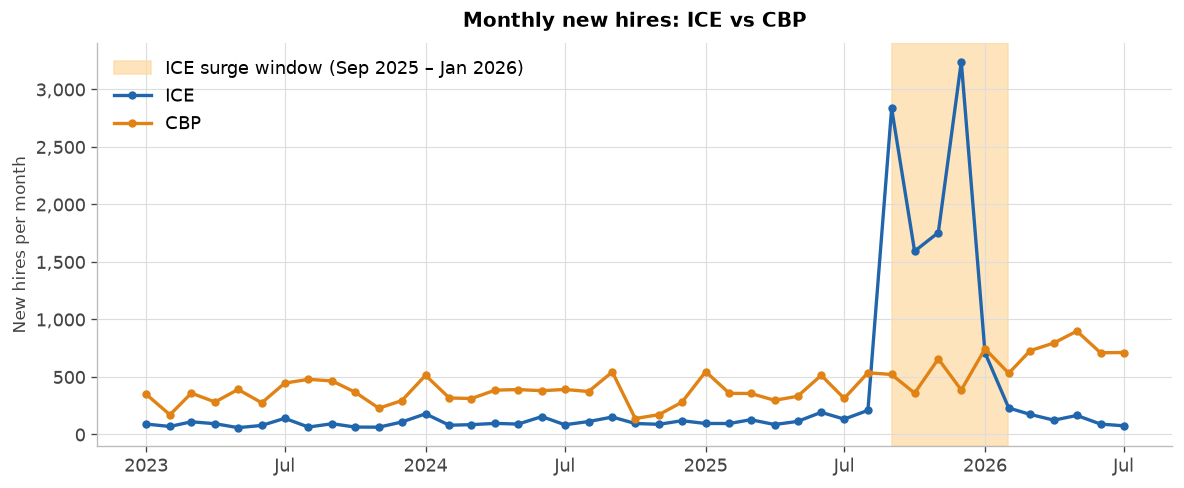

In [9]:
monthly = q(f"""
  SELECT event_ym,
    SUM(CASE WHEN {ICE_HIRE} THEN count END) AS ICE,
    SUM(CASE WHEN agy_code='{surge.CBP}' AND {surge.NEW_HIRE} THEN count END) AS CBP
  FROM '{ACC}' WHERE event_ym >= '202301' GROUP BY 1 ORDER BY 1
""")
monthly["date"] = pd.to_datetime(monthly.event_ym, format="%Y%m")
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.axvspan(pd.Timestamp("2025-09-01"), pd.Timestamp("2026-01-31"), color=SPAN, alpha=.7, zorder=0,
           label="ICE surge window (Sep 2025 – Jan 2026)")
ax.plot(monthly.date, monthly.ICE, marker="o", ms=4, lw=2, color=C_ICE, label="ICE")
ax.plot(monthly.date, monthly.CBP, marker="o", ms=4, lw=2, color=C_CBP, label="CBP")
ax.set(title="Monthly new hires: ICE vs CBP", ylabel="New hires per month")
comma_y(ax); date_x(ax); ax.legend(loc="upper left"); fig.tight_layout()

surge_win = monthly.query(f"'{surge.SURGE_WINDOW[0]}' <= event_ym <= '{surge.SURGE_WINDOW[1]}'")
surge_win_ice, surge_win_peak = int(surge_win.ICE.sum()), surge_win.loc[surge_win.ICE.idxmax()]
print(f"ICE new hires, Sep 2025 – Jan 2026: {surge_win_ice:,}")

In [10]:
display(Markdown(
    f"The ICE surge is a **sharp burst from Sep 2025 to Jan 2026** — {surge_win_ice:,} hires in five "
    f"months, peaking in {ym_label(surge_win_peak.event_ym)} — then it drops back to roughly normal "
    f"monthly levels. CBP shows no comparable spike; it ramps up gradually and later, into 2026."
))

The ICE surge is a **sharp burst from Sep 2025 to Jan 2026** — 10,133 hires in five months, peaking in Dec 2025 — then it drops back to roughly normal monthly levels. CBP shows no comparable spike; it ramps up gradually and later, into 2026.

### 1b. How does this compare to *past* ICE hiring?

To see whether this is unusual for ICE, we extend the series back to 2006 (from the raw yearly files,
pulled by `src/history.py`; the agency codes were verified stable back to 2008 in §0) and join it to the
2018-onward cached extract.

ICE annual new hires — prior peak: 1,966 in 2009  |  2025: 10,474  (5.3x the prior peak)
CBP annual new hires — prior peak: 9,130 in 2008


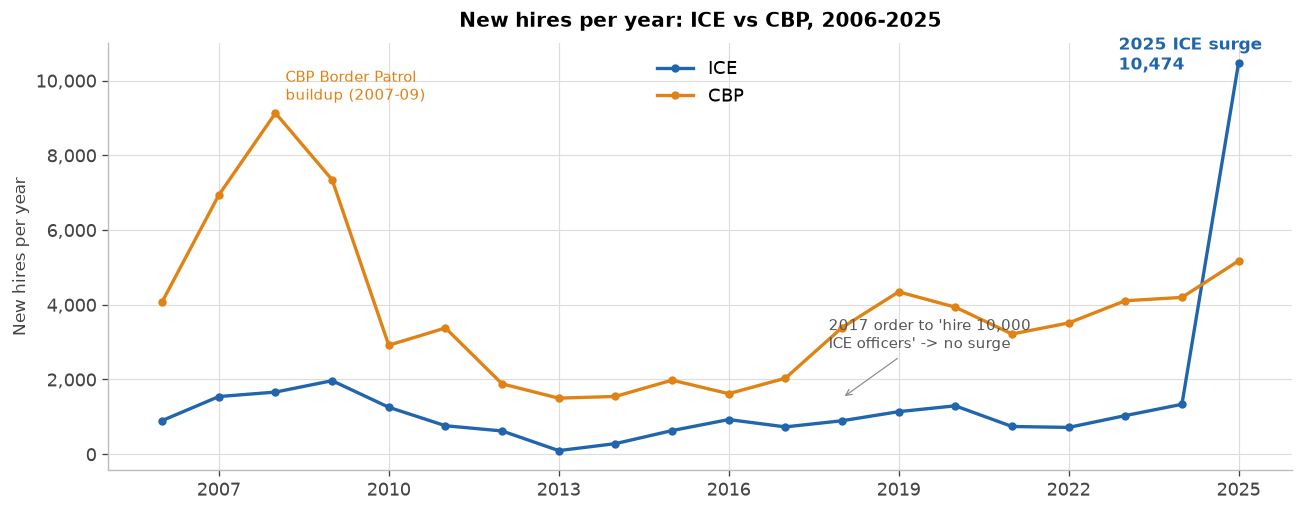

In [11]:
hist = pd.read_csv("data/ice_cbp_hires_history.csv")  # 2006-2017, from src/history.py
long = (hist.pivot_table(index="year", columns="agy", values="new_hires", aggfunc="sum")
            .rename(columns={"HSBB":"ICE","HSBD":"CBP"}))
recent = by_year.set_index("year").rename(columns={"ice_new_hires":"ICE","cbp_new_hires":"CBP"})[["ICE","CBP"]]
recent.index = recent.index.astype(int)
arc = pd.concat([long, recent]).sort_index()
arc = arc[arc.index <= 2025]  # 2026 is partial, drop it from the annual view
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(arc.index, arc.ICE, marker="o", ms=4, lw=2, color=C_ICE, label="ICE")
ax.plot(arc.index, arc.CBP, marker="o", ms=4, lw=2, color=C_CBP, label="CBP")
ax.annotate("CBP Border Patrol\nbuildup (2007-09)", (2008, arc.CBP.loc[2008]),
            textcoords="offset points", xytext=(6, 8), fontsize=9, color=C_CBP)
ax.annotate("2017 order to 'hire 10,000\nICE officers' -> no surge", (2018, 1500),
            textcoords="offset points", xytext=(-8, 30), fontsize=9, color="#555",
            arrowprops=dict(arrowstyle="->", lw=.7, color="#888"))
ax.annotate(f"2025 ICE surge\n{int(arc.ICE.loc[2025]):,}", (2025, arc.ICE.loc[2025]),
            textcoords="offset points", xytext=(-72, -4), fontsize=10, color=C_ICE, fontweight="bold")
ax.set(title="New hires per year: ICE vs CBP, 2006-2025", ylabel="New hires per year")
comma_y(ax); int_x(ax); ax.legend(loc="upper center"); fig.tight_layout()

ice_prior_peak, ice_prior_peak_yr = arc.ICE.loc[:2024].max(), int(arc.ICE.loc[:2024].idxmax())
cbp_prior_peak, cbp_prior_peak_yr = arc.CBP.loc[:2024].max(), int(arc.CBP.loc[:2024].idxmax())
post_order = arc.ICE.loc[2018:2020]  # the three years after the 2017 "hire 10,000" executive order
print(f"ICE annual new hires — prior peak: {int(ice_prior_peak):,} in {ice_prior_peak_yr}"
      f"  |  2025: {int(arc.ICE.loc[2025]):,}  ({arc.ICE.loc[2025]/ice_prior_peak:.1f}x the prior peak)")
print(f"CBP annual new hires — prior peak: {int(cbp_prior_peak):,} in {cbp_prior_peak_yr}")

In [12]:
cbp_buildup = arc.CBP.loc[2007:2009]
display(Markdown(
    f"**2025 is the biggest hiring year in ICE's record.** ICE's previous *annual* record was "
    f"{int(ice_prior_peak):,} new hires ({ice_prior_peak_yr}); 2025's {int(arc.ICE.loc[2025]):,} is "
    f"**{arc.ICE.loc[2025]/ice_prior_peak:.0f}× ICE's all-time record and {arc.ICE.loc[2025]/pre_ice.max():.0f}× "
    f"its recent norm**. Notably, the **2017 executive order that directed hiring 10,000 more ICE "
    f"officers produced no visible surge** — ICE hiring stayed near {int(post_order.min()):,}–"
    f"{int(post_order.max()):,} a year through 2020. The only thing in this data that *looks* like 2025 "
    f"is **CBP in 2007–2009**, when the Bush-era Border Patrol buildup drove {int(cbp_buildup.min()):,}–"
    f"{int(cbp_buildup.max()):,} hires a year. So the 2025 ICE surge resembles CBP's 2007–2009 buildup, at a "
    f"larger scale; and CBP's most recent rapid entry-officer push, in 2019–21, also saw unusually high "
    f"first-year attrition (§4b)."
))

**2025 is the biggest hiring year in ICE's record.** ICE's previous *annual* record was 1,966 new hires (2009); 2025's 10,474 is **5× ICE's all-time record and 8× its recent norm**. Notably, the **2017 executive order that directed hiring 10,000 more ICE officers produced no visible surge** — ICE hiring stayed near 893–1,293 a year through 2020. The only thing in this data that *looks* like 2025 is **CBP in 2007–2009**, when the Bush-era Border Patrol buildup drove 6,935–9,130 hires a year. So the 2025 ICE surge resembles CBP's 2007–2009 buildup, at a larger scale; and CBP's most recent rapid entry-officer push, in 2019–21, also saw unusually high first-year attrition (§4b).

## 2. Did it stick — did the hires stay on the rolls?

Hires are a monthly *flow*. The headcount file is the *level* — how many people are actually on the
payroll each month. If the surge is real and the hires stayed, ICE headcount should jump and hold.

ICE: Aug 2025 = 20,848  ->  peak Jan 2026 = 30,461  ->  Jul 2026 = 28,861
ICE change since the Jan 2026 peak: -1,600 (-5.3%)


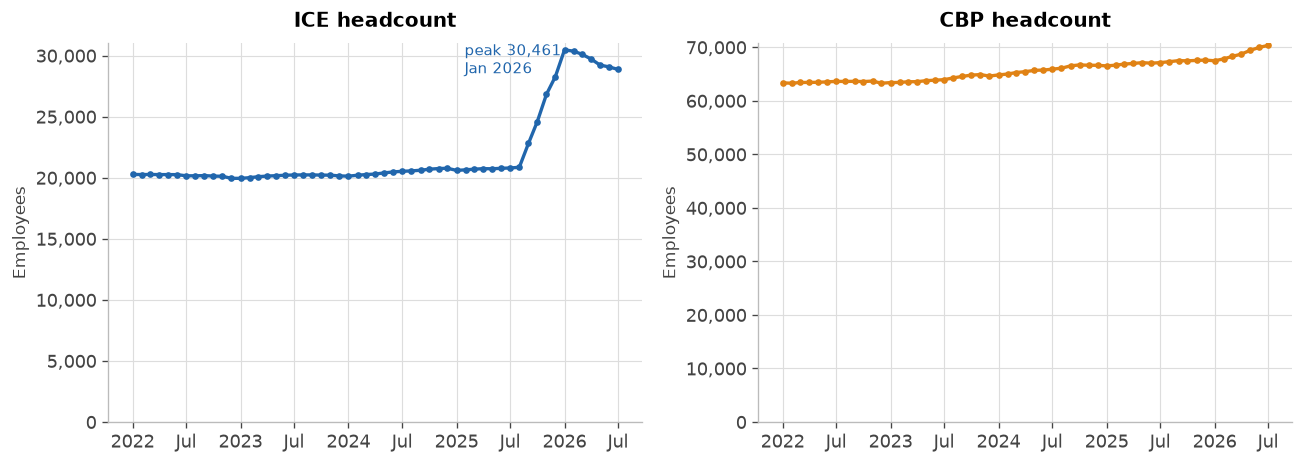

In [13]:
head = q(f"""
  SELECT snapshot_ym,
    SUM(CASE WHEN {IS_ICE} THEN count END) AS ICE,
    SUM(CASE WHEN agy_code='{surge.CBP}' THEN count END) AS CBP
  FROM '{EMP}' GROUP BY 1 ORDER BY 1
""")
head["date"] = pd.to_datetime(head.snapshot_ym, format="%Y%m")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, col, c in zip(axes, ["ICE", "CBP"], [C_ICE, C_CBP]):
    ax.plot(head.date, head[col], color=c, marker="o", ms=3, lw=2)
    ax.set(title=f"{col} headcount", ylabel="Employees"); ax.set_ylim(bottom=0)
    comma_y(ax); date_x(ax)
peak = head.loc[head.ICE.idxmax()]
axes[0].annotate(f"peak {int(peak.ICE):,}\n{ym_label(peak.snapshot_ym)}", (peak.date, peak.ICE),
                 textcoords="offset points", xytext=(-60, -14), fontsize=9, color=C_ICE)
fig.tight_layout()
aug25 = int(head.query(f"snapshot_ym=='{PRE_SURGE_MONTH}'").ICE.iloc[0]); latest = int(head.iloc[-1].ICE)
print(f"ICE: {ym_label(PRE_SURGE_MONTH)} = {aug25:,}  ->  peak {ym_label(peak.snapshot_ym)} = {int(peak.ICE):,}"
      f"  ->  {ym_label(head.iloc[-1].snapshot_ym)} = {latest:,}")
print(f"ICE change since the Jan 2026 peak: {latest-int(peak.ICE):+,} ({(latest/peak.ICE-1)*100:+.1f}%)")

In [14]:
pct_expand = (int(peak.ICE) / aug25 - 1) * 100
pct_slip = (latest / peak.ICE - 1) * 100
trend_word = "edged down" if pct_slip > -10 else "dropped"
display(Markdown(
    f"The surge **did** reach the rolls: ICE headcount jumps from about {aug25:,} (Aug 2025) to a peak "
    f"of **{int(peak.ICE):,} in {ym_label(peak.snapshot_ym)}** — a ~{pct_expand:.0f}% expansion in five "
    f"months. It has since **{trend_word}** — by the latest month ICE is at about {latest:,}, "
    f"down roughly {int(peak.ICE)-latest:,} ({pct_slip:.0f}%) from the peak, even though some hiring "
    f"continued. ICE remains well above its pre-surge level, but Sections 3–4 show it is the surge hires "
    f"themselves leaving. CBP grows slowly and steadily, with no reversal. (Headcount and the "
    f"hires-minus-departures flow don't match exactly — a data quirk covered in caveat 4 of §5, not part "
    f"of the staffing story.)"
))

The surge **did** reach the rolls: ICE headcount jumps from about 20,848 (Aug 2025) to a peak of **30,461 in Jan 2026** — a ~46% expansion in five months. It has since **edged down** — by the latest month ICE is at about 28,861, down roughly 1,600 (-5%) from the peak, even though some hiring continued. ICE remains well above its pre-surge level, but Sections 3–4 show it is the surge hires themselves leaving. CBP grows slowly and steadily, with no reversal. (Headcount and the hires-minus-departures flow don't match exactly — a data quirk covered in caveat 4 of §5, not part of the staffing story.)

## 3. Who are the surge hires? (Building a profile)

With no person IDs, to ask "are the *surge hires* the ones leaving" we first need a **profile** — the
job attributes that separate surge hires from normal ICE hires. We scan each attribute and rank its
values by how much more common they are among surge hires than in normal hiring. We measure that with
**"× vs. baseline" = (share among surge hires) ÷ (share among 2024 hires)**; a value of 3.0 means it is
three times as common in the surge. The two decisive attributes — **job series** and **pay plan** — are
shown as tables; grade, appointment type, and age are summarized in the reading that follows.

In [15]:
baseline_2024 = "event_ym BETWEEN '202401' AND '202412'"  # the "normal hiring" comparison year for this profile
Bt, St = con.execute(f"SELECT SUM(CASE WHEN {baseline_2024} THEN count END), SUM(CASE WHEN {SURGE_WINDOW_SQL} THEN count END) FROM '{ACC}' WHERE {ICE_HIRE}").fetchone()

def fingerprint(col, min_n=150):
    d = q(f"SELECT {col} AS value, SUM(CASE WHEN {baseline_2024} THEN count END) b, SUM(CASE WHEN {SURGE_WINDOW_SQL} THEN count END) s FROM '{ACC}' WHERE {ICE_HIRE} GROUP BY 1")
    d[["b","s"]] = d[["b","s"]].fillna(0)
    d["% of surge"]    = (100*d.s/St).round(1)
    d["% of 2024"]     = (100*d.b/Bt).round(1)
    d["× vs 2024"]     = (d["% of surge"]/d["% of 2024"]).round(1)
    d["surge hires"]   = d.s.astype(int)
    return (d[d.s>=min_n].sort_values("s", ascending=False)
             .rename(columns={"value": col})
             [[col,"surge hires","% of surge","% of 2024","× vs 2024"]].reset_index(drop=True))

labels = {"occupational_series_code":"Job series", "pay_plan_code":"Pay plan",
          "appointment_type":"Appointment type", "grade":"Grade", "age_bracket":"Age bracket"}
display(Markdown(f"**ICE new hires — 2024 baseline = {int(Bt):,} &nbsp;·&nbsp; surge window = {int(St):,}**"))
fp_tables = {}
for c in ["occupational_series_code","pay_plan_code"]:
    fp_df = fingerprint(c)
    fp_tables[c] = fp_df
    disp = fp_df.copy()
    if c == "occupational_series_code":
        disp[c] = disp[c].map(series_label)   # show "1801 — General Inspection..." not just "1801"
    disp = disp.rename(columns={c: labels[c]})
    display(Markdown(f"**{labels[c]}**"))
    display(show(disp, pct=["% of surge","% of 2024"]))

# Secondary markers (appointment type, age, grade), used in the "Reading the profile" cell below —
# not shown as tables since job series and pay plan already carry the finding.
fp_appt = fingerprint("appointment_type", min_n=1)
fp_age = fingerprint("age_bracket", min_n=1)
term_row = fp_appt[fp_appt.appointment_type.str.contains("NONPERMANENT", case=False)].iloc[0]
age_older = fp_age[fp_age.age_bracket.isin(["50-54","55-59"])]
gl_grades = q(f"SELECT grade, SUM(count) n FROM '{ACC}' WHERE {ICE_HIRE} AND {SURGE_WINDOW_SQL} AND pay_plan_code='GL' GROUP BY 1 ORDER BY n DESC")
gl_top_grades = "/".join(sorted(gl_grades.head(3).grade))

**ICE new hires — 2024 baseline = 1,334 &nbsp;·&nbsp; surge window = 10,133**

**Job series**

Job series,surge hires,% of surge,% of 2024,× vs 2024
"1801 — General Inspection, Investigation, Enforcement, and Compliance Series","6,445",63.6%,19.9%,3.2
1811 — Criminal Investigation,"2,335",23.0%,19.2%,1.2
0905 — Attorney,987,9.7%,25.3%,0.4


**Pay plan**

Pay plan,surge hires,% of surge,% of 2024,× vs 2024
GL,"6,884",67.9%,32.6%,2.1
GS,"3,244",32.0%,67.1%,0.5


In [16]:
s_df = fp_tables["occupational_series_code"].set_index("occupational_series_code")
p_df = fp_tables["pay_plan_code"].set_index("pay_plan_code")
r1801, r1811, rGL = s_df.loc["1801"], s_df.loc["1811"], p_df.loc["GL"]
combined_1801_1811 = r1801["% of surge"] + r1811["% of surge"]

display(Markdown(
    f"**Reading the profile:**\n\n"
    f"- **Job series** is the sharpest marker: series **1801** (*{occ_names.get('1801','')}* — the ICE "
    f"immigration-enforcement / deportation officer series) is about {r1801['% of surge']:.0f}% of surge "
    f"hires versus {r1801['% of 2024']:.0f}% in normal hiring (**{r1801['× vs 2024']:.1f}× as common**); "
    f"adding series **1811** (*{occ_names.get('1811','')}*) covers about {combined_1801_1811:.0f}% of the surge.\n"
    f"- **Pay plan `GL`** (the entry law-enforcement officer pay plan) is about {rGL['% of surge']:.0f}% of "
    f"surge hires versus {rGL['% of 2024']:.0f}% normally (**{rGL['× vs 2024']:.1f}×**), at grades "
    f"**GL-{gl_top_grades}**.\n"
    f"- Two secondary markers: an unusual share of **term (non-permanent) appointments** "
    f"(**{term_row['× vs 2024']:.1f}×**), and an **older age mix** (the 50–59 brackets run "
    f"{age_older['× vs 2024'].min():.1f}–{age_older['× vs 2024'].max():.1f}× normal) — atypical for "
    f"entry-level law-enforcement.\n\n"
    f"So we define the surge hires as **pay plan `GL` + job series 1801/1811**. Almost no one at ICE held "
    f"those jobs before the surge, so any jump in departures from them is, by construction, the surge "
    f"hires — **and this does not use length of service**, which is muddied by prior federal experience "
    f"(see §5)."
))

**Reading the profile:**

- **Job series** is the sharpest marker: series **1801** (*General Inspection, Investigation, Enforcement, and Compliance Series* — the ICE immigration-enforcement / deportation officer series) is about 64% of surge hires versus 20% in normal hiring (**3.2× as common**); adding series **1811** (*Criminal Investigation*) covers about 87% of the surge.
- **Pay plan `GL`** (the entry law-enforcement officer pay plan) is about 68% of surge hires versus 33% normally (**2.1×**), at grades **GL-05/07/09**.
- Two secondary markers: an unusual share of **term (non-permanent) appointments** (**3.0×**), and an **older age mix** (the 50–59 brackets run 1.5–2.8× normal) — atypical for entry-level law-enforcement.

So we define the surge hires as **pay plan `GL` + job series 1801/1811**. Almost no one at ICE held those jobs before the surge, so any jump in departures from them is, by construction, the surge hires — **and this does not use length of service**, which is muddied by prior federal experience (see §5).

## 4. Are the surge hires the ones leaving — and are they quitting or being let go?

Now apply the same profile to **departures**: exits from the GL-1801/1811 jobs over time.

In [17]:
fp_sep_year = q(f"""
  SELECT substr(event_ym,1,4) AS year, SUM(count) AS fp_separations,
    SUM(CASE WHEN separation_category='QUIT' THEN count END) AS quits,
    SUM(CASE WHEN separation_category LIKE 'TERMINATION%' THEN count END) AS terminations
  FROM '{SEP}' WHERE {ICE_FP_SEP} GROUP BY 1 ORDER BY 1
""")
show(fp_sep_year.rename(columns={"year":"Year","fp_separations":"Departures",
                                 "quits":"Quits","terminations":"Terminations"}))

Year,Departures,Quits,Terminations
2018,28,19,—
2019,27,7,—
2020,46,16,1
2021,43,29,—
2022,37,19,—
2023,27,12,—
2024,32,21,—
2025,739,564,148
2026,"1,303",840,393


In [18]:
pre_dep = fp_sep_year[(fp_sep_year.year >= "2018") & (fp_sep_year.year <= "2024")].fp_separations
dep_2025 = int(fp_sep_year.loc[fp_sep_year.year == "2025", "fp_separations"].iloc[0])
dep_2026 = int(fp_sep_year.loc[fp_sep_year.year == "2026", "fp_separations"].iloc[0])
months_2026 = int(surge.LATEST_MONTH[4:])  # e.g. "202607" -> 7 months of 2026 so far
pct_vs_2025 = 100 * (dep_2026 - dep_2025) / dep_2025
pre_dep_monthly, now_monthly = pre_dep.mean() / 12, dep_2026 / months_2026
pace_x = now_monthly / pre_dep_monthly

display(Markdown(
    f"Departures from these jobs were a **flat {int(pre_dep.min())}–{int(pre_dep.max())} per year from "
    f"2018 through 2024**. They jump to **{dep_2025:,} in 2025** and **{dep_2026:,} in just the first "
    f"{months_2026} months of 2026** — already {pct_vs_2025:.0f}% more than all of 2025, in "
    f"{'barely half' if months_2026 <= 7 else 'well under'} the year — a monthly pace roughly "
    f"**{pace_x:.0f}× the pre-surge norm**. The exits begin the same month the hiring does (Sep 2025). "
    f"The monthly picture, next to hiring, is in the chart further down."
))

Departures from these jobs were a **flat 27–46 per year from 2018 through 2024**. They jump to **739 in 2025** and **1,303 in just the first 7 months of 2026** — already 76% more than all of 2025, in barely half the year — a monthly pace roughly **65× the pre-surge norm**. The exits begin the same month the hiring does (Sep 2025). The monthly picture, next to hiring, is in the chart further down.

### Let go, or leaving on their own?

The departure category tells voluntary quits apart from involuntary terminations.

In [19]:
why = q(f"""
  SELECT separation_category, SUM(count) AS n
  FROM '{SEP}' WHERE {ICE_FP_SEP} AND {POST_SURGE}
  GROUP BY 1 ORDER BY n DESC
""")
why["share_%"] = (100*why.n/why.n.sum()).round(1)
q_ct = int(why.loc[why.separation_category=='QUIT','n'].iloc[0])
t_ct = int(why.loc[why.separation_category.str.startswith('TERMINATION'),'n'].sum())
display(show(why.rename(columns={"separation_category":"Departure type","n":"People"}), pct=["share_%"]))
print(f"Voluntary QUIT: {q_ct:,} ({100*q_ct/why.n.sum():.0f}%)   Involuntary TERMINATION: {t_ct:,} ({100*t_ct/why.n.sum():.0f}%)")

Departure type,People,share_%
QUIT,"1,374",69.1%
TERMINATION (EXPIRED APPT/OTHER),538,27.1%
TRANSFER OUT - INDIVIDUAL TRANSFER,38,1.9%
OTHER SEPARATION,34,1.7%
RETIREMENT - VOLUNTARY,3,0.2%


Voluntary QUIT: 1,374 (69%)   Involuntary TERMINATION: 538 (27%)


In [20]:
q_pct, t_pct = 100 * q_ct / why.n.sum(), 100 * t_ct / why.n.sum()
display(Markdown(
    f"**Most are voluntary departures, not removals.** Of departures from the surge hires since Sep "
    f"2025, about **{q_pct:.0f}% are voluntary quits** and about **{t_pct:.0f}% are terminations** coded "
    f"\"expired appointment / other.\" The termination category combines **term (non-permanent) "
    f"appointments reaching their end** (the {term_row['× vs 2024']:.1f}× term-appointment share from §3) "
    f"with any probationary removals, and the data does not separate the two."
))

**Most are voluntary departures, not removals.** Of departures from the surge hires since Sep 2025, about **69% are voluntary quits** and about **27% are terminations** coded "expired appointment / other." The termination category combines **term (non-permanent) appointments reaching their end** (the 3.0× term-appointment share from §3) with any probationary removals, and the data does not separate the two.

Month,Hires,Quits,Appointment ended,Departures total
Jun 2025,98,3,0,4
Jul 2025,62,5,1,8
Aug 2025,109,3,2,8
Sep 2025,"1,769",46,6,53
Oct 2025,811,210,66,276
Nov 2025,"1,092",156,39,199
Dec 2025,"2,704",122,34,156
Jan 2026,508,158,63,235
Feb 2026,134,192,74,270
Mar 2026,79,174,87,277


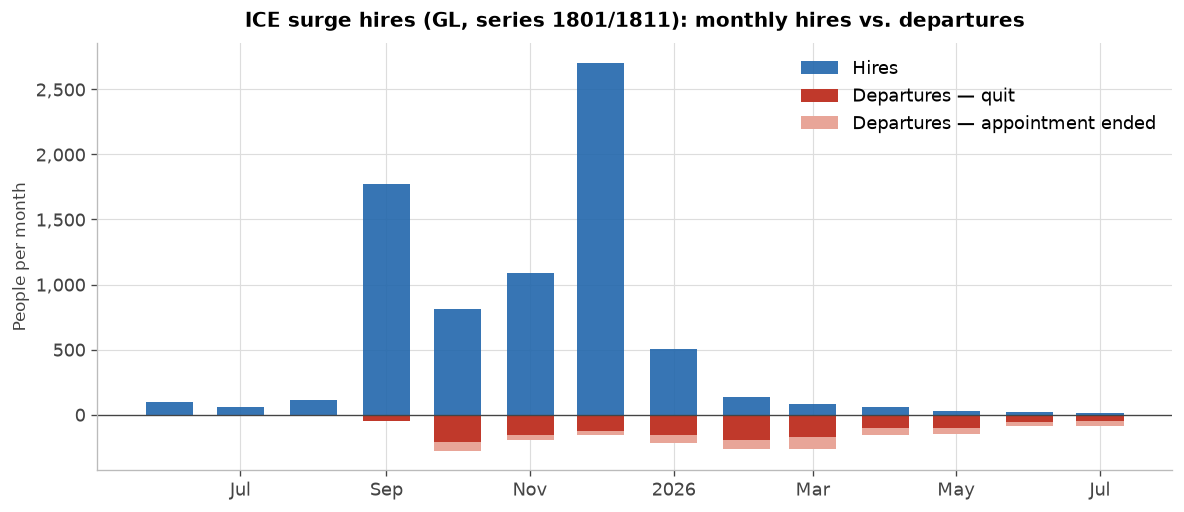

In [21]:
# Hires (up) vs. departures (down, split into quit vs. term-ended), on ONE shared scale so the
# proportion leaving reads consistently: departures are small next to the hiring wave, then dominate
# once hiring stops.
comp = q(f"""
  WITH h AS (SELECT event_ym, SUM(count) hires FROM '{ACC}' WHERE {ICE_FP_HIRE} GROUP BY 1),
       s AS (SELECT event_ym,
               SUM(CASE WHEN separation_category='QUIT' THEN count END) quits,
               SUM(CASE WHEN separation_category LIKE 'TERMINATION%' THEN count END) terms,
               SUM(count) exits
             FROM '{SEP}' WHERE {ICE_FP_SEP} GROUP BY 1)
  SELECT COALESCE(h.event_ym,s.event_ym) event_ym, COALESCE(hires,0) hires,
         COALESCE(quits,0) quits, COALESCE(terms,0) terms, COALESCE(exits,0) exits
  FROM h FULL JOIN s USING(event_ym)
  WHERE COALESCE(h.event_ym,s.event_ym) >= '202506' ORDER BY 1
""")
comp["date"] = pd.to_datetime(comp.event_ym, format="%Y%m")
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.bar(comp.date, comp.hires, width=20, color=C_ICE, alpha=.9, label="Hires")
ax.bar(comp.date, -comp.quits, width=20, color=C_EXIT, label="Departures — quit")
ax.bar(comp.date, -comp.terms, bottom=-comp.quits, width=20, color="#e8a598",
       label="Departures — appointment ended")
ax.axhline(0, color="#444", lw=.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{abs(x):,.0f}"))
ax.set(title="ICE surge hires (GL, series 1801/1811): monthly hires vs. departures",
       ylabel="People per month"); date_x(ax); ax.legend(loc="upper right"); fig.tight_layout()
comp_disp = comp.assign(Month=comp.event_ym.map(ym_label))[["Month","hires","quits","terms","exits"]]
comp_disp.columns = ["Month","Hires","Quits","Appointment ended","Departures total"]
display(show(comp_disp))

A wall of hiring in **Sep 2025 – Jan 2026**, then hiring falls off a cliff while departures stay
elevated — so from about Feb 2026 the group **shrinks every month**. That is the mechanism behind the
headcount reversal in §2.

### 4b. How many leave soon after being hired — and is that rate unusual?

Because these jobs were nearly empty before the surge, we can watch the **whole group's** departures pile
up against its own hires — a running early-departure rate that does **not** depend on length of service
(so it also captures the ~30% of surge hires who had prior federal experience).

By Jul 2026: 1,987 of 7,214 surge hires have left = 27.5% — all within their first year, and still climbing.


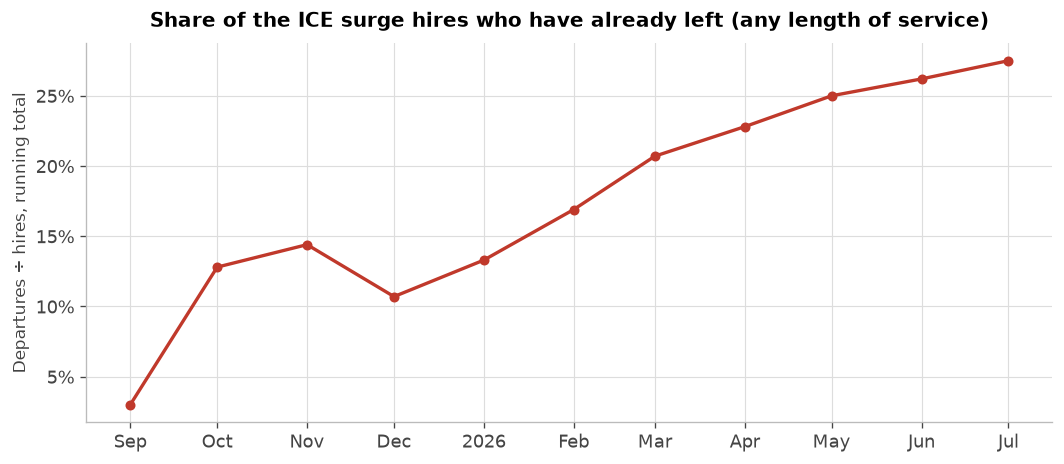

In [22]:
cohort = q(f"""
  WITH h AS (SELECT event_ym, SUM(count) hires FROM '{ACC}' WHERE {ICE_FP_HIRE} GROUP BY 1),
       s AS (SELECT event_ym, SUM(count) exits FROM '{SEP}' WHERE {ICE_FP_SEP} GROUP BY 1)
  SELECT m.event_ym,
    SUM(COALESCE(hires,0)) OVER w AS cum_hires,
    SUM(COALESCE(exits,0)) OVER w AS cum_exits,
    ROUND(100.0*SUM(COALESCE(exits,0)) OVER w / NULLIF(SUM(COALESCE(hires,0)) OVER w,0),1) AS pct_of_cohort_exited
  FROM (SELECT event_ym FROM h UNION SELECT event_ym FROM s) m
  LEFT JOIN h USING(event_ym) LEFT JOIN s USING(event_ym)
  WHERE {POST_SURGE} WINDOW w AS (ORDER BY m.event_ym) ORDER BY m.event_ym
""")
cohort["date"] = pd.to_datetime(cohort.event_ym, format="%Y%m")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cohort.date, cohort.pct_of_cohort_exited, marker="o", ms=5, lw=2, color=C_EXIT)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set(title="Share of the ICE surge hires who have already left (any length of service)",
       ylabel="Departures ÷ hires, running total"); date_x(ax); fig.tight_layout()
final = cohort.iloc[-1]
print(f"By {ym_label(final.event_ym)}: {int(final.cum_exits):,} of {int(final.cum_hires):,} surge hires have left "
      f"= {final.pct_of_cohort_exited}% — all within their first year, and still climbing.")

In [23]:
display(Markdown(
    f"About **{final.pct_of_cohort_exited:.0f}%** of surge hires ({int(final.cum_exits):,} of "
    f"{int(final.cum_hires):,}) have already left, and the share climbs every month because hiring "
    f"stopped while departures continue.\n\n"
    f"Is that a lot? We can't yet answer with an ICE *first-year* rate — these hires arrived Sep 2025 – "
    f"Jan 2026, so by {ym_label(final.event_ym)} the earliest of them have only about "
    f"{(pd.to_datetime(final.event_ym, format='%Y%m') - pd.Timestamp('2025-09-01')).days // 30} months on "
    f"the job, still short of a full year for the cohort as a whole, and annualizing a partial year would "
    f"mislead. What we *can* compute is the **completed** first-year rate for a genuinely similar group: "
    f"**CBP's entry law-enforcement officers** — Border Patrol Agents (series 1896, *Border Patrol "
    f"Enforcement*, GL) and CBP Officers (series 1895, *Customs and Border Protection*). Same DHS "
    f"enforcement mission, same entry grades, same academy onboarding, but hired in volume every year, so "
    f"their cohorts have each had a full year or more to play out. Those give honest full-year benchmarks "
    f"to hold ICE's partial-year loss against — a comparison of *horizons*, not rate-against-rate. (The "
    f"CBP measure: departures with under a year of service ÷ new-entrant hires.)"
))

About **28%** of surge hires (1,987 of 7,214) have already left, and the share climbs every month because hiring stopped while departures continue.

Is that a lot? We can't yet answer with an ICE *first-year* rate — these hires arrived Sep 2025 – Jan 2026, so by Jul 2026 the earliest of them have only about 10 months on the job, still short of a full year for the cohort as a whole, and annualizing a partial year would mislead. What we *can* compute is the **completed** first-year rate for a genuinely similar group: **CBP's entry law-enforcement officers** — Border Patrol Agents (series 1896, *Border Patrol Enforcement*, GL) and CBP Officers (series 1895, *Customs and Border Protection*). Same DHS enforcement mission, same entry grades, same academy onboarding, but hired in volume every year, so their cohorts have each had a full year or more to play out. Those give honest full-year benchmarks to hold ICE's partial-year loss against — a comparison of *horizons*, not rate-against-rate. (The CBP measure: departures with under a year of service ÷ new-entrant hires.)

In [24]:
def first_year_rate(agy, profile_filter, y0, y1):
    d = q(f"""
      WITH h AS (SELECT SUM(CASE WHEN {surge.dbl('length_of_service_years')}<0.15 THEN count END) hires
                 FROM '{ACC}' WHERE agy_code='{agy}' AND {surge.NEW_HIRE} AND {profile_filter}
                   AND substr(event_ym,1,4) BETWEEN '{y0}' AND '{y1}'),
           s AS (SELECT SUM(CASE WHEN {surge.dbl('length_of_service_years')}<1 THEN count END) exits_lt1yr
                 FROM '{SEP}' WHERE agy_code='{agy}' AND {profile_filter}
                   AND substr(event_ym,1,4) BETWEEN '{y0}' AND '{y1}')
      SELECT hires, exits_lt1yr, ROUND(100.0*exits_lt1yr/NULLIF(hires,0),1) first_yr_sep_pct FROM h,s
    """).iloc[0]
    return int(d.hires), int(d.exits_lt1yr), d.first_yr_sep_pct

# No ICE row on purpose: these hires are only a few months into their first year, so an ICE first-year
# rate isn't computable yet. ICE's observed loss so far (chart above) is compared to these full-year
# CBP benchmarks by horizon, in words, below.
rows = [
  ("CBP Border Patrol (1896 GL) — 2023-24 classes", "HSBD", "pay_plan_code='GL' AND occupational_series_code='1896'", "2023","2024"),
  ("CBP Border Patrol (1896 GL) — 2019-21 rapid-hire", "HSBD", "pay_plan_code='GL' AND occupational_series_code='1896'", "2019","2021"),
  ("CBP Officer (1895) — 2023-24 classes", "HSBD", "occupational_series_code='1895'", "2023","2024"),
]
cbp = pd.DataFrame([(lbl,)+first_year_rate(a,f,y0,y1) for lbl,a,f,y0,y1 in rows],
                   columns=["group","new_entrant_hires","exits_under_1yr","first_yr_sep_%"])
display(Markdown("**Reference — CBP departures within the _full_ first year of service (completed cohorts)**"))
display(show(cbp.rename(columns={"group":"CBP entry law-enforcement group","new_entrant_hires":"New-entrant hires",
                                 "exits_under_1yr":"Left within first year","first_yr_sep_%":"First-year rate"}),
             pct=["First-year rate"]))
print(f"ICE surge hires so far (chart above): {int(final.cum_exits):,} of {int(final.cum_hires):,} left "
      f"= {final.pct_of_cohort_exited}% — before their first year is complete, so not shown as a rate.")

**Reference — CBP departures within the _full_ first year of service (completed cohorts)**

CBP entry law-enforcement group,New-entrant hires,Left within first year,First-year rate
CBP Border Patrol (1896 GL) — 2023-24 classes,"1,977",226,11.4%
CBP Border Patrol (1896 GL) — 2019-21 rapid-hire,"3,275",944,28.8%
CBP Officer (1895) — 2023-24 classes,"2,075",218,10.5%


ICE surge hires so far (chart above): 1,987 of 7,214 left = 27.5% — before their first year is complete, so not shown as a rate.


In [25]:
cbp_normal = cbp[cbp.group.str.contains("2023-24")]["first_yr_sep_%"]
cbp_surge = cbp[cbp.group.str.contains("2019-21")]["first_yr_sep_%"].iloc[0]
position = "near the high end of" if final.pct_of_cohort_exited <= cbp_surge else "beyond"
display(Markdown(
    f"**The verdict.** We can't state an ICE *first-year* rate — the cohort's first year isn't over "
    f"(these hires are only a few months in), and annualizing a partial year would mislead. What we can "
    f"say: ICE has **already lost about {final.pct_of_cohort_exited:.0f}%** before that first year is up. "
    f"For a full-year reference, CBP's comparable entry classes lose about **{cbp_normal.min():.0f}–"
    f"{cbp_normal.max():.0f}% over a whole year** in normal times, and even CBP's roughest rapid-hire "
    f"cohort — Border Patrol in **2019–21** — lost about **{cbp_surge:.0f}% over a whole year**. So in "
    f"well under a year ICE has already passed CBP's steady-state full-year loss and is closing on CBP's "
    f"own worst rapid-hire surge — {position} that range, with its first year not yet complete."
))

**The verdict.** We can't state an ICE *first-year* rate — the cohort's first year isn't over (these hires are only a few months in), and annualizing a partial year would mislead. What we can say: ICE has **already lost about 28%** before that first year is up. For a full-year reference, CBP's comparable entry classes lose about **10–11% over a whole year** in normal times, and even CBP's roughest rapid-hire cohort — Border Patrol in **2019–21** — lost about **29% over a whole year**. So in well under a year ICE has already passed CBP's steady-state full-year loss and is closing on CBP's own worst rapid-hire surge — near the high end of that range, with its first year not yet complete.

In [26]:
# Control-group check: does a comparable, growing, but non-surged group also see elevated
# attrition -- or is this specific to ICE's surge? CBP's entry-officer jobs (Border Patrol
# series 1896-GL, CBP Officer 1895) are the closest analog: same kind of entry
# law-enforcement work, and CBP also grew this group substantially over the same window --
# just without ICE's compressed, 8x-normal-pace burst. If fast growth alone were what
# elevates attrition, CBP's rate should have moved too.
cbp_prof = "pay_plan_code='GL' AND occupational_series_code IN ('1896','1895')"
cbp_where = f"agy_code='{surge.CBP}'"

cbp_baseline = q(f"""
  WITH d AS (SELECT substr(event_ym,1,4) AS yr, SUM(count) AS deps FROM '{SEP}'
             WHERE {cbp_where} AND {cbp_prof} AND substr(event_ym,1,4) IN ('2023','2024') GROUP BY 1),
       h AS (SELECT substr(snapshot_ym,1,4) AS yr, AVG(count) AS avg_hc FROM '{EMP}'
             WHERE {cbp_where} AND {cbp_prof} AND substr(snapshot_ym,1,4) IN ('2023','2024') GROUP BY 1)
  SELECT d.yr, d.deps, h.avg_hc, 100.0*d.deps/h.avg_hc AS rate_pct
  FROM d JOIN h ON d.yr = h.yr ORDER BY d.yr
""")
cbp_deps_window = int(scalar(f"SELECT SUM(count) FROM '{SEP}' WHERE {cbp_where} AND {cbp_prof} AND {POST_SURGE}"))
cbp_avg_hc_window = scalar(f"SELECT AVG(count) FROM '{EMP}' WHERE {cbp_where} AND {cbp_prof} AND snapshot_ym >= '{surge.SURGE_WINDOW[0]}'")
cbp_rate_window = 100 * cbp_deps_window / cbp_avg_hc_window
cbp_hc_start = int(scalar(f"SELECT SUM(count) FROM '{EMP}' WHERE {cbp_where} AND {cbp_prof} AND snapshot_ym='{PRE_SURGE_MONTH}'"))
cbp_hc_latest = int(scalar(f"SELECT SUM(count) FROM '{EMP}' WHERE {cbp_where} AND {cbp_prof} AND snapshot_ym='{surge.LATEST_MONTH}'"))

display(Markdown(
    f"**Control group.** CBP grew this group substantially over the same window -- headcount "
    f"{cbp_hc_start:,}\u2192{cbp_hc_latest:,} ({100*(cbp_hc_latest/cbp_hc_start-1):.0f}%) -- but its "
    f"attrition rate didn't move: **{cbp_rate_window:.1f}%** over the same {window_months} months "
    f"(\u2248{cbp_rate_window*12/window_months:.1f}% annualized), against its own "
    f"**{cbp_baseline.rate_pct.min():.1f}-{cbp_baseline.rate_pct.max():.1f}%** 2023-24 baseline -- in "
    f"range, not a spike. What's different about ICE isn't growth; it's the shape of it -- compressed "
    f"into five months at 8x normal pace, versus CBP's steadier build."
))

**Control group.** CBP grew this group substantially over the same window -- headcount 2,374→4,816 (103%) -- but its attrition rate didn't move: **9.4%** over the same 11 months (≈10.3% annualized), against its own **7.3-9.6%** 2023-24 baseline -- in range, not a spike. What's different about ICE isn't growth; it's the shape of it -- compressed into five months at 8x normal pace, versus CBP's steadier build.

Check 5's observed rate (6.6-6.9%/yr) explains only 4.6-4.8% of tracked departures. Triple it, to ~21%/yr -- never observed in this job group -- and the headline number only drops from 27.5% to 23.6%.
=> The base group would have to lose more people than its entire headcount within these 11 months (143%/year) to explain all tracked departures on its own.


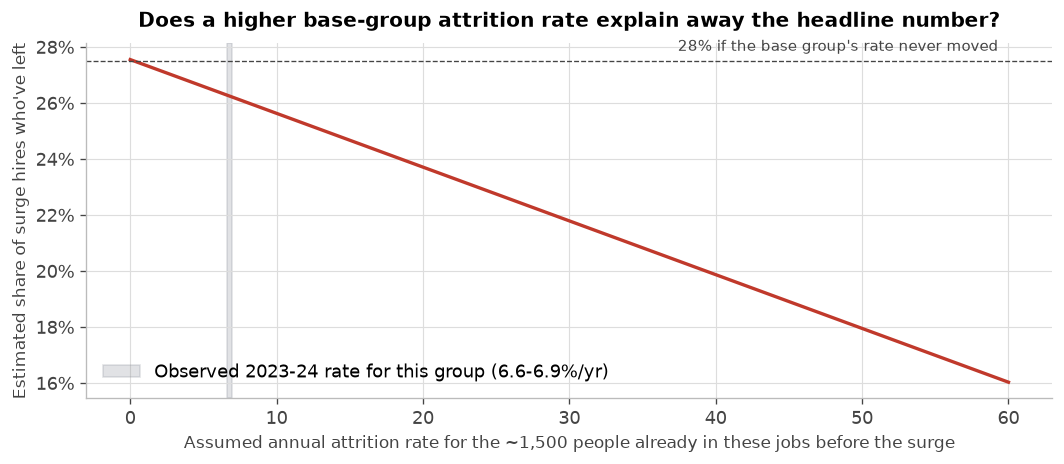

In [27]:
# Sensitivity check: Check 5 (§0) bounded the pre-existing population's contribution to tracked
# departures using THAT group's own observed 2023-24 attrition rate, held flat through the surge.
# What if it didn't hold flat -- what if elevated attrition (worse morale, more scrutiny, whatever)
# hit the base group too, not just the surge hires? Sweep the assumed rate and see how far the
# headline number would have to move before the base group's own turnover could explain it away.
sweep = pd.DataFrame({"assumed_rate": [r / 2 for r in range(0, 121)]})  # 0-60%/yr, half-point steps
sweep["base_departures"] = pre_surge_hc * (sweep.assumed_rate / 100) * window_months / 12
sweep["adjusted_pct_exited"] = 100 * (tracked_departures - sweep.base_departures) / final.cum_hires
breakeven_rate = 100 * tracked_departures / (pre_surge_hc * window_months / 12)

fig, ax = plt.subplots(figsize=(9, 4))
ax.axvspan(rate_years.rate_pct.min(), rate_years.rate_pct.max(), color=C_MUTED, alpha=.25, zorder=0,
           label=f"Observed 2023-24 rate for this group ({rate_years.rate_pct.min():.1f}-"
                 f"{rate_years.rate_pct.max():.1f}%/yr)")
ax.plot(sweep.assumed_rate, sweep.adjusted_pct_exited, lw=2, color=C_EXIT)
ax.axhline(final.pct_of_cohort_exited, color="#444", lw=.8, ls="--")
ax.annotate(f"{final.pct_of_cohort_exited:.0f}% if the base group's rate never moved",
            (sweep.assumed_rate.max(), final.pct_of_cohort_exited), xytext=(-6, 6),
            textcoords="offset points", ha="right", fontsize=9, color="#444")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set(title="Does a higher base-group attrition rate explain away the headline number?",
       xlabel="Assumed annual attrition rate for the ~1,500 people already in these jobs before the surge",
       ylabel="Estimated share of surge hires who've left")
ax.legend(loc="lower left"); fig.tight_layout()

rate_3x = 3 * rate_years.rate_pct.max()
pct_at_3x = 100 * (tracked_departures - pre_surge_hc * (rate_3x / 100) * window_months / 12) / final.cum_hires
print(f"Check 5's observed rate ({rate_years.rate_pct.min():.1f}-{rate_years.rate_pct.max():.1f}%/yr) "
      f"explains only {100*baseline_lo/tracked_departures:.1f}-{100*baseline_hi/tracked_departures:.1f}% "
      f"of tracked departures. Triple it, to ~{rate_3x:.0f}%/yr -- never observed in this job group -- "
      f"and the headline number only drops from {final.pct_of_cohort_exited:.1f}% to {pct_at_3x:.1f}%.")
print(f"=> The base group would have to lose more people than its entire headcount within these "
      f"{window_months} months ({breakeven_rate:.0f}%/year) to explain all tracked departures on its "
      f"own.")


This job group's own settled months: only 52% of eventual departures show up in the event month's own file (vs. ~99% for a typical ICE+CBP month, §0 check 3) -- it takes about 5 more months of filings to reach 95%. (The reference total itself may still inch up a little more -- if anything, an underestimate.)
Applying that curve to the months still filling in: an estimated 2,251 total departures once they finish landing, vs. 1,987 reported so far -- 13% more. => actual current attrition is likely closer to 31.2% than the raw 27.5% figure quoted above, with most of the gap sitting in the last 1-3 months, right where the running chart above looks like it's leveling off.


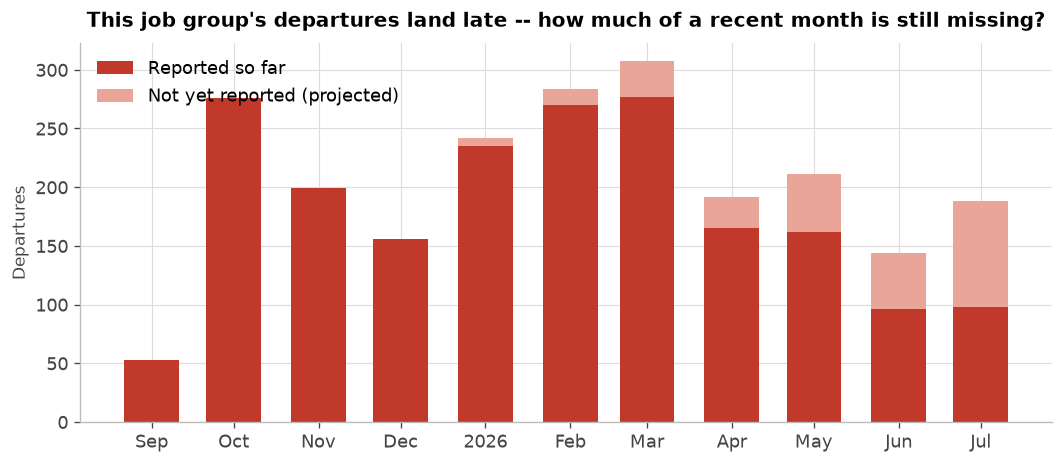

In [28]:
# Is this cohort's attrition landing late? Check 3 (§0) found a typical ICE+CBP separations month is
# ~99% complete in its own file. That check pooled EVERY separation, mostly routine. This cohort's
# exits -- probationary terminations, DRP-flagged resignations -- may process more slowly. Rebuild the
# same completion-by-lag curve using just this job group's own now-settled early months (Sep-Dec 2025,
# each with 7+ months of later files behind it), then use it to project what the recent, still-thin
# months will look like once they finish landing.
settle = q(f"""
  WITH x AS (SELECT event_ym, SUM(count) n,
      (CAST(substr(file_ym,1,4) AS INT)*12+CAST(substr(file_ym,5,2) AS INT))
     -(CAST(substr(event_ym,1,4) AS INT)*12+CAST(substr(event_ym,5,2) AS INT)) AS lag
    FROM '{SEP}' WHERE {ICE_FP_SEP} AND event_ym BETWEEN '202509' AND '202512' GROUP BY 1, file_ym)
  SELECT lag, SUM(n) n FROM x WHERE lag BETWEEN 0 AND 6 GROUP BY 1 ORDER BY 1
""")
ref_total = int(scalar(f"SELECT SUM(count) FROM '{SEP}' WHERE {ICE_FP_SEP} AND event_ym BETWEEN '202509' AND '202512'"))
settle["cum_pct"] = 100 * settle.n.cumsum() / ref_total

ref_monthly = q(f"""
  SELECT event_ym, SUM(count) AS reported FROM '{SEP}'
  WHERE {ICE_FP_SEP} AND event_ym BETWEEN '202509' AND '202512' GROUP BY 1 ORDER BY 1
""")
ref_monthly["projected"] = ref_monthly.reported  # settled months -- no adjustment needed

lag_bars = q(f"""
  SELECT event_ym, SUM(count) AS reported,
    (CAST(substr('{surge.LATEST_MONTH}',1,4) AS INT)*12+CAST(substr('{surge.LATEST_MONTH}',5,2) AS INT))
   -(CAST(substr(event_ym,1,4) AS INT)*12+CAST(substr(event_ym,5,2) AS INT)) AS months_of_files
  FROM '{SEP}' WHERE {ICE_FP_SEP} AND event_ym > '202512' GROUP BY 1 ORDER BY 1
""")
lag_bars["capped_lag"] = lag_bars.months_of_files.clip(upper=settle.lag.max())
lag_bars = lag_bars.merge(settle[["lag", "cum_pct"]], left_on="capped_lag", right_on="lag", how="left")
lag_bars["projected"] = lag_bars.reported / (lag_bars.cum_pct / 100)

bars = pd.concat([ref_monthly[["event_ym", "reported", "projected"]],
                   lag_bars[["event_ym", "reported", "projected"]]], ignore_index=True)
bars["still_to_land"] = bars.projected - bars.reported
bars["date"] = pd.to_datetime(bars.event_ym, format="%Y%m")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bars.date, bars.reported, width=20, color=C_EXIT, label="Reported so far")
ax.bar(bars.date, bars.still_to_land, bottom=bars.reported, width=20, color="#e8a598",
       label="Not yet reported (projected)")
ax.set(title="This job group's departures land late -- how much of a recent month is still missing?",
       ylabel="Departures"); date_x(ax); ax.legend(loc="upper left"); fig.tight_layout()

projected_total = ref_total + lag_bars.projected.sum()
adjusted_pct = 100 * projected_total / final.cum_hires
months_to_95 = int(settle.loc[settle.cum_pct >= 95, "lag"].min())
print(f"This job group's own settled months: only {settle.cum_pct.iloc[0]:.0f}% of eventual departures "
      f"show up in the event month's own file (vs. ~99% for a typical ICE+CBP month, §0 check 3) -- it "
      f"takes about {months_to_95} more months of filings to reach 95%. (The reference total itself may "
      f"still inch up a little more -- if anything, an underestimate.)")
print(f"Applying that curve to the months still filling in: an estimated {projected_total:,.0f} total "
      f"departures once they finish landing, vs. {tracked_departures:,} reported so far -- "
      f"{projected_total/tracked_departures - 1:.0%} more. => actual current attrition is likely closer "
      f"to {adjusted_pct:.1f}% than the raw {final.pct_of_cohort_exited:.1f}% figure quoted above, with "
      f"most of the gap sitting in the last 1-3 months, right where the running chart above looks like "
      f"it's leveling off.")


In [29]:
pre_surge_profile_hc = int(scalar(f"SELECT SUM(count) FROM '{EMP}' WHERE {ICE_FP_SEP} AND snapshot_ym='{PRE_SURGE_MONTH}'"))
attorneys = int(scalar(f"""SELECT SUM(count) FROM '{ACC}' WHERE {ICE_HIRE}
    AND {SURGE_WINDOW_SQL} AND occupational_series_code='0905'"""))
tot_dep_window = int(scalar(f"SELECT SUM(count) FROM '{SEP}' WHERE {IS_ICE} AND {POST_SURGE}"))
drp_cohort = q(f"SELECT COALESCE(drp_indicator,'(blank)') AS d, SUM(count) AS n FROM '{SEP}' WHERE {ICE_FP_SEP} AND {POST_SURGE} GROUP BY 1")
drp_all = q(f"SELECT COALESCE(drp_indicator,'(blank)') AS d, SUM(count) AS n FROM '{SEP}' WHERE {IS_ICE} AND {POST_SURGE} GROUP BY 1")
drp_yes_cohort = int(drp_cohort.loc[drp_cohort.d == "Y", "n"].sum())
drp_yes_all = int(drp_all.loc[drp_all.d == "Y", "n"].sum())
window_fp = int(scalar(f"SELECT SUM(count) FROM '{ACC}' WHERE {ICE_FP_HIRE} AND {SURGE_WINDOW_SQL}"))
fp_coverage_pct = 100 * window_fp / St  # St (§3, cell above) is the same surge-window ICE-hire total
prior_2025 = q(f"""
  SELECT CASE WHEN {surge.dbl('length_of_service_years')} >= 3 THEN 1 ELSE 0 END AS is_3plus, SUM(count) AS n
  FROM '{ACC}' WHERE {ICE_HIRE} AND substr(event_ym,1,4)='2025' GROUP BY 1
""")
prior_3plus_pct = 100 * prior_2025.set_index("is_3plus").loc[1, "n"] / prior_2025.n.sum()

# Caveat 9 -- headcount for this specific job/pay-plan slice fell further, since the peak,
# than hires-minus-departures explains. Same question we already answer for ICE overall
# (caveat 4): how much bigger is it here, and which direction does the gap point? Every
# number quoted in caveat 9 below is computed here, live -- including the "ruled out"
# checks, none of which are asserted without a query backing them.
profile_hc_peak = int(scalar(f"SELECT SUM(count) FROM '{EMP}' WHERE {ICE_FP_SEP} AND snapshot_ym='{peak.snapshot_ym}'"))
profile_hc_latest = int(scalar(f"SELECT SUM(count) FROM '{EMP}' WHERE {ICE_FP_SEP} AND snapshot_ym='{surge.LATEST_MONTH}'"))
since_peak = f"event_ym > '{peak.snapshot_ym}' AND event_ym <= '{surge.LATEST_MONTH}'"
profile_flow = int(scalar(f"SELECT SUM(count) FROM '{ACC}' WHERE {ICE_FP_HIRE} AND {since_peak}")) \
             - int(scalar(f"SELECT SUM(count) FROM '{SEP}' WHERE {ICE_FP_SEP} AND {since_peak}"))
profile_gap = (profile_hc_latest - profile_hc_peak) - profile_flow
profile_gap_pct = 100 * abs(profile_gap) / abs(profile_hc_latest - profile_hc_peak)

ice_flow = int(scalar(f"SELECT SUM(count) FROM '{ACC}' WHERE {IS_ICE} AND {surge.NEW_HIRE} AND {since_peak}")) \
         - int(scalar(f"SELECT SUM(count) FROM '{SEP}' WHERE {IS_ICE} AND {since_peak}"))
ice_gap = (latest - int(peak.ICE)) - ice_flow
ice_gap_pct = 100 * abs(ice_gap) / abs(latest - int(peak.ICE))

# Ruled out 1: promotion into GS-paid 1801/1811 -- if this were the surge cohort itself
# converting pay plans, those new GS accessions would be brand-new-to-service, not
# experienced hires.
gs_prior = q(f"""
  SELECT CASE WHEN {surge.dbl('length_of_service_years')} >= 3 THEN 1 ELSE 0 END is3plus, SUM(count) n
  FROM '{ACC}' WHERE {IS_ICE} AND pay_plan_code='GS' AND occupational_series_code IN ('1801','1811')
    AND {POST_SURGE} AND accession_category LIKE 'NEW HIRE%' GROUP BY 1
""")
gs_prior_pct = 100 * gs_prior.set_index("is3plus").loc[1, "n"] / gs_prior.n.sum()

# Ruled out 2: a mass-transfer administrative recoding event.
mass_transfer_n = int(scalar(f"""SELECT COALESCE(SUM(count),0) FROM '{SEP}' WHERE {ICE_FP_SEP}
    AND separation_category='TRANSFER OUT - MASS TRANSFER' AND {POST_SURGE}"""))

# Ruled out 3: reclassification to a different pay plan under the same series -- every
# 1801/1811 pay plan besides GL/GS, peak vs. latest.
other_pp = q(f"""
  SELECT pay_plan_code, SUM(CASE WHEN snapshot_ym='{peak.snapshot_ym}' THEN count END) peak_n,
         SUM(CASE WHEN snapshot_ym='{surge.LATEST_MONTH}' THEN count END) latest_n
  FROM '{EMP}' WHERE {IS_ICE} AND occupational_series_code IN ('1801','1811')
    AND pay_plan_code NOT IN ('GL','GS') AND snapshot_ym IN ('{peak.snapshot_ym}','{surge.LATEST_MONTH}')
  GROUP BY 1
""")
other_pp_peak, other_pp_latest = int(other_pp.peak_n.sum()), int(other_pp.latest_n.sum())

# Not-a-data-dropout check: does the decline concentrate in one age bracket or grade (a
# suppression/miscoding signature) or is it broad? The cached EMP extract doesn't carry
# age_bracket/grade, so this queries the raw HF employment files directly for just the
# two snapshot months needed.
_file_map = json.load(open("data/hf_file_map.json"))
_emp_url = lambda ym: f"https://huggingface.co/datasets/impactproject/opm-ehri-data/resolve/main/{_file_map['employment'][ym]}"
_urls = f"['{_emp_url(peak.snapshot_ym)}','{_emp_url(surge.LATEST_MONTH)}']"
_chg = lambda col: con.execute(f"""
  SELECT {col},
    100.0*(SUM(CASE WHEN snapshot_yyyymm='{surge.LATEST_MONTH}' THEN TRY_CAST(count AS INT) END)
         - SUM(CASE WHEN snapshot_yyyymm='{peak.snapshot_ym}' THEN TRY_CAST(count AS INT) END))
      / SUM(CASE WHEN snapshot_yyyymm='{peak.snapshot_ym}' THEN TRY_CAST(count AS INT) END) AS pct_chg
  FROM read_parquet({_urls}, union_by_name=true)
  WHERE agency_subelement_code='{surge.ICE}' AND pay_plan_code='GL' AND occupational_series_code IN ('1801','1811')
  GROUP BY 1
""").df()
age_chg, grade_chg = _chg("age_bracket"), _chg("grade")

display(Markdown(
    f"## 5. Net effect, and what the data can and cannot say\n\n"
    f"**Net effect.** The 2025 surge was overwhelmingly ICE, reached the payroll (headcount +"
    f"{pct_expand:.0f}%), and is now unwinding as the surge hires themselves leave — headcount down "
    f"{abs(pct_slip):.0f}% off the January peak, {final.pct_of_cohort_exited:.0f}% of the cohort gone "
    f"before its first year is even up, mostly by voluntary quit. The charts above carry the numbers; "
    f"the caveats below cover what this data can't settle.\n\n"
    f"**Caveats (each checked or bounded in §0):**\n\n"
    f"1. **Counts, not people.** We match *departing* jobs to *hiring* jobs, not tracked individuals — "
    f"tight only because ICE had few people in these entry jobs before the surge "
    f"(~{pre_surge_profile_hc:,} in Aug 2025, small next to the {int(final.cum_hires):,} hired into "
    f"them). Some tracked departures could still be that pre-existing group leaving at its "
    f"normal pace, not surge hires — bounded in §0 check 5 at roughly "
    f"{100*baseline_lo/tracked_departures:.1f}-{100*baseline_hi/tracked_departures:.1f}% of what "
    f"we count, even at the high end -- and tripling that group's assumed rate only pulls the "
    f"headline number from {final.pct_of_cohort_exited:.1f}% to {pct_at_3x:.1f}% (sensitivity "
    f"check above).\n"
    f"2. **We track the ~{fp_coverage_pct:.0f}% we can.** The profile (GL, 1801/1811) covers about "
    f"{fp_coverage_pct:.0f}% of surge-window hires — the entry officers. The rest (GS officers and "
    f"~{attorneys:,} attorneys) sit in jobs with large standing populations, so their attrition can't be "
    f"isolated the same way.\n"
    f"3. **Length of service ≠ time in this job.** About {prior_3plus_pct:.0f}% of 2025 ICE new hires "
    f"arrived with 3+ years of prior federal service (veterans and rehires, not transfers — those are "
    f"0.4%, §0) — exactly why we profile by job and grade instead (full breakdown below).\n"
    f"4. **Headcount and flow don't reconcile** (§2) — flow lags the headcount change, so we use "
    f"headcount for levels and departures for exits, never chained.\n"
    f"5. **Recent months are provisional, and this job group's separations land later than a typical "
    f"month** (§0 check 3; quantified above) — correcting for that reporting lag puts current "
    f"attrition closer to **{adjusted_pct:.0f}%** than the raw **{final.pct_of_cohort_exited:.0f}%** "
    f"quoted above -- if anything, this **understates** recent exits.\n"
    f"6. **Term vs. cause.** \"Termination\" mixes term-appointment expirations with any for-cause "
    f"removals; can't be split further.\n"
    f"7. **Redaction preserves totals** (§0 check 4) — masked fields are relabeled, not dropped.\n"
    f"8. **Not a buyout artifact.** {drp_yes_cohort} of the {int(final.cum_exits):,} cohort departures — "
    f"and {drp_yes_all} of all {tot_dep_window:,} ICE departures in this window — are flagged as "
    f"deferred-resignation-program exits.\n"
    f"9. **Headcount for this job slice fell more than hires-minus-departures explains.** Since the "
    f"January peak, GL/1801/1811 headcount is down {abs(profile_hc_latest-profile_hc_peak):,}; flow "
    f"only accounts for {abs(profile_flow):,} of that -- a {profile_gap_pct:.0f}% unexplained gap. ICE "
    f"overall has a smaller version of the same gap ({ice_gap_pct:.0f}%, already caveat 4), so some "
    f"mismatch is normal, but this group's is about {profile_gap_pct/ice_gap_pct:.0f}x larger. Checked "
    f"and ruled out: promotion to GS 1801/1811 -- a separate, senior-hire stream, not the surge cohort "
    f"converting pay plans ({gs_prior_pct:.0f}% of those new GS hires arrive with 3+ years of prior "
    f"federal service, not people a year into their first job); a mass-transfer recoding event "
    f"({mass_transfer_n} recorded); and reclassification to another pay plan in the same series "
    f"({other_pp_peak}→{other_pp_latest} people across every non-GL/GS pay plan, essentially flat). The "
    f"decline also isn't concentrated in one age or grade cell (a data-suppression signature) -- every "
    f"age bracket fell {abs(age_chg.pct_chg).min():.0f}-{abs(age_chg.pct_chg).max():.0f}%, every grade "
    f"{abs(grade_chg.pct_chg).min():.0f}-{abs(grade_chg.pct_chg).max():.0f}% (steepest at the most junior "
    f"grade, consistent with probationary washout, not an anomaly). Mechanism for the remainder is "
    f"unresolved. **Likely direction:** since the closest analog (caveat 4/ICE-wide) already points to "
    f"undercounted exits, not overcounted ones, this gap is more likely to mean the "
    f"{final.pct_of_cohort_exited:.0f}% figure is a floor than a ceiling -- we found nothing suggesting "
    f"it overstates departures."
))

## 5. Net effect, and what the data can and cannot say

**Net effect.** The 2025 surge was overwhelmingly ICE, reached the payroll (headcount +46%), and is now unwinding as the surge hires themselves leave — headcount down 5% off the January peak, 28% of the cohort gone before its first year is even up, mostly by voluntary quit. The charts above carry the numbers; the caveats below cover what this data can't settle.

**Caveats (each checked or bounded in §0):**

1. **Counts, not people.** We match *departing* jobs to *hiring* jobs, not tracked individuals — tight only because ICE had few people in these entry jobs before the surge (~1,511 in Aug 2025, small next to the 7,214 hired into them). Some tracked departures could still be that pre-existing group leaving at its normal pace, not surge hires — bounded in §0 check 5 at roughly 4.6-4.8% of what we count, even at the high end -- and tripling that group's assumed rate only pulls the headline number from 27.5% to 23.6% (sensitivity check above).
2. **We track the ~68% we can.** The profile (GL, 1801/1811) covers about 68% of surge-window hires — the entry officers. The rest (GS officers and ~987 attorneys) sit in jobs with large standing populations, so their attrition can't be isolated the same way.
3. **Length of service ≠ time in this job.** About 30% of 2025 ICE new hires arrived with 3+ years of prior federal service (veterans and rehires, not transfers — those are 0.4%, §0) — exactly why we profile by job and grade instead (full breakdown below).
4. **Headcount and flow don't reconcile** (§2) — flow lags the headcount change, so we use headcount for levels and departures for exits, never chained.
5. **Recent months are provisional, and this job group's separations land later than a typical month** (§0 check 3; quantified above) — correcting for that reporting lag puts current attrition closer to **31%** than the raw **28%** quoted above -- if anything, this **understates** recent exits.
6. **Term vs. cause.** "Termination" mixes term-appointment expirations with any for-cause removals; can't be split further.
7. **Redaction preserves totals** (§0 check 4) — masked fields are relabeled, not dropped.
8. **Not a buyout artifact.** 0 of the 1,987 cohort departures — and 0 of all 4,098 ICE departures in this window — are flagged as deferred-resignation-program exits.
9. **Headcount for this job slice fell more than hires-minus-departures explains.** Since the January peak, GL/1801/1811 headcount is down 1,822; flow only accounts for 738 of that -- a 59% unexplained gap. ICE overall has a smaller version of the same gap (20%, already caveat 4), so some mismatch is normal, but this group's is about 3x larger. Checked and ruled out: promotion to GS 1801/1811 -- a separate, senior-hire stream, not the surge cohort converting pay plans (99% of those new GS hires arrive with 3+ years of prior federal service, not people a year into their first job); a mass-transfer recoding event (0 recorded); and reclassification to another pay plan in the same series (55→50 people across every non-GL/GS pay plan, essentially flat). The decline also isn't concentrated in one age or grade cell (a data-suppression signature) -- every age bracket fell 16-32%, every grade 11-35% (steepest at the most junior grade, consistent with probationary washout, not an anomaly). Mechanism for the remainder is unresolved. **Likely direction:** since the closest analog (caveat 4/ICE-wide) already points to undercounted exits, not overcounted ones, this gap is more likely to mean the 28% figure is a floor than a ceiling -- we found nothing suggesting it overstates departures.

**Supporting detail for caveat 8** — the same DRP check, broken out by flag:

In [30]:
# drp_cohort is the exact same query, already run for §5 caveat 8 -- reused here, not re-queried.
show(drp_cohort.sort_values("n", ascending=False).rename(
    columns={"d": "DRP flag (Y = deferred-resignation program)", "n": "Cohort departures"}))

DRP flag (Y = deferred-resignation program),Cohort departures
N,"1,987"


**The stock-vs-flow gap behind caveat 4, month by month.** ICE headcount change vs. hires − departures
around the surge: they tell the same story but don't match exactly, most visibly at the Dec 2025 / Jan
2026 boundary, where December-effective hires only land on the January headcount.

In [31]:
recon = q(f"""
  WITH e AS (SELECT snapshot_ym ym, SUM(count) hc FROM '{EMP}' WHERE {IS_ICE} GROUP BY 1),
       a AS (SELECT event_ym ym, SUM(count) acc FROM '{ACC}' WHERE {IS_ICE} GROUP BY 1),
       s AS (SELECT event_ym ym, SUM(count) sep FROM '{SEP}' WHERE {IS_ICE} GROUP BY 1)
  SELECT e.ym, hc, hc - LAG(hc) OVER (ORDER BY e.ym) AS d_headcount,
         acc, sep, acc - sep AS net_flow
  FROM e LEFT JOIN a ON a.ym=e.ym LEFT JOIN s ON s.ym=e.ym
  WHERE e.ym BETWEEN '{PRE_SURGE_MONTH}' AND '{surge.LATEST_MONTH}' ORDER BY e.ym
""")
recon_disp = recon.assign(Month=recon.ym.map(ym_label))[["Month","hc","d_headcount","acc","sep","net_flow"]]
recon_disp.columns = ["Month","Headcount","Change vs. prior month","Hires","Departures","Hires − departures"]
show(recon_disp)

Month,Headcount,Change vs. prior month,Hires,Departures,Hires − departures
Aug 2025,"20,848",—,215,125,90
Sep 2025,"22,799","1,951","2,839",183,"2,656"
Oct 2025,"24,593","1,794","1,598",447,"1,151"
Nov 2025,"26,827","2,234","1,756",336,"1,420"
Dec 2025,"28,272","1,445","3,269",497,"2,772"
Jan 2026,"30,461","2,189",715,496,219
Feb 2026,"30,355",-106,230,482,-252
Mar 2026,"30,102",-253,177,453,-276
Apr 2026,"29,714",-388,128,315,-187
May 2026,"29,219",-495,166,359,-193


In [32]:
prior = q(f"""
  SELECT CASE WHEN {surge.dbl('length_of_service_years')} < 0.15 THEN 'Truly new (under 2 months of service)'
              WHEN {surge.dbl('length_of_service_years')} < 3 THEN 'Some prior federal service (under 3 yr)'
              ELSE '3+ years of prior federal service' END AS prior_experience,
         SUM(count) AS n
  FROM '{ACC}' WHERE {ICE_HIRE} AND substr(event_ym,1,4)='2025'
  GROUP BY 1 ORDER BY n DESC
""")
prior["share_%"] = (100*prior.n/prior.n.sum()).round(1)
show(prior.rename(columns={"prior_experience":"Prior federal service","n":"People"}), pct=["share_%"])

Prior federal service,People,share_%
Truly new (under 2 months of service),"6,752",64.5%
3+ years of prior federal service,"3,132",29.9%
Some prior federal service (under 3 yr),590,5.6%


In [33]:
p3plus_share = prior.set_index("prior_experience").loc["3+ years of prior federal service", "share_%"]
display(Markdown(
    f"About {p3plus_share:.0f}% of 2025 ICE \"new hires\" arrived with **3+ years of prior federal "
    f"service** — rehires, conversions, and moves from other agencies entering as new appointments. This "
    f"is exactly why the surge hires have to be identified by **the job they were hired into**, not by "
    f"how long they've been on a federal payroll.\n\n"
    f"---\n"
    f"*Source: OPM/EHRI hires, departures, and headcount via `impactproject/opm-ehri-data`; extract built "
    f"by `src/extract.py`; the surge-hire definition and windows are in `src/surge.py`. ICE = HSBB, CBP = "
    f"HSBD. Data through {ym_label(surge.LATEST_MONTH)}; the most recent 1–2 months are provisional.*"
))

About 30% of 2025 ICE "new hires" arrived with **3+ years of prior federal service** — rehires, conversions, and moves from other agencies entering as new appointments. This is exactly why the surge hires have to be identified by **the job they were hired into**, not by how long they've been on a federal payroll.

---
*Source: OPM/EHRI hires, departures, and headcount via `impactproject/opm-ehri-data`; extract built by `src/extract.py`; the surge-hire definition and windows are in `src/surge.py`. ICE = HSBB, CBP = HSBD. Data through Jul 2026; the most recent 1–2 months are provisional.*